In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [ ]:
df = pd.read_csv("Bank_Loan_Approval_Dataset.csv")
df.head()

,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Employment_Type,Existing_Liabilities,Property_Area,Age,Loan_Status
0,136958,26736,580089,300,369,Self-employed,210977,Urban,38,0
1,146932,854,200262,300,551,Salaried,12910,Rural,47,0
2,118694,38623,492905,240,714,Self-employed,335623,Rural,54,0
3,134879,7392,285362,120,744,Salaried,470951,Semi-Urban,47,0
4,125268,55680,494209,60,481,Self-employed,81264,Semi-Urban,37,0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Applicant_Income      150 non-null    int64 
 1   Coapplicant_Income    150 non-null    int64 
 2   Loan_Amount           150 non-null    int64 
 3   Loan_Term_Months      150 non-null    int64 
 4   Credit_Score          150 non-null    int64 
 5   Employment_Type       150 non-null    object
 6   Existing_Liabilities  150 non-null    int64 
 7   Property_Area         150 non-null    object
 8   Age                   150 non-null    int64 
 9   Loan_Status           150 non-null    int64 
dtypes: int64(8), object(2)
memory usage: 11.8+ KB


,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Existing_Liabilities,Age,Loan_Status
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,86595.340000,37899.046667,487666.253333,198.400000,580.306667,243350.820000,40.746667,0.100000
std,41653.343527,22925.974435,268044.270036,97.554528,170.862830,144414.554396,11.019925,0.301005
min,15769.000000,301.000000,53051.000000,60.000000,300.000000,846.000000,21.000000,0.000000
25%,52309.750000,18199.750000,263848.250000,120.000000,426.750000,117860.000000,31.000000,0.000000
50%,83494.000000,39003.500000,493557.000000,180.000000,553.500000,251793.000000,42.000000,0.000000
75%,125913.500000,55447.000000,713848.250000,300.000000,736.750000,366571.500000,50.000000,0.000000
max,149633.000000,79909.000000,999597.000000,360.000000,893.000000,487005.000000,59.000000,1.000000


In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
svm_linear = SVC(kernel='linear')

svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

In [ ]:
svm_rbf = SVC(kernel='rbf')

svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

In [ ]:
svm_poly = SVC(kernel='poly')

svm_poly.fit(X_train, y_train)

y_pred_poly = svm_poly.predict(X_test)

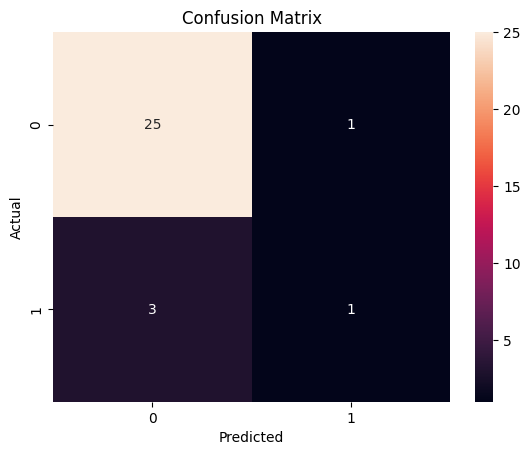

In [ ]:
cm = confusion_matrix(y_test, y_pred_linear)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))
print("RBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Polynomial Kernel Accuracy:", accuracy_score(y_test, y_pred_poly))

Linear Kernel Accuracy: 0.8666666666666667
RBF Kernel Accuracy: 0.8666666666666667
Polynomial Kernel Accuracy: 0.8666666666666667


In [ ]:
print("Linear Kernel Report")
print(classification_report(y_test, y_pred_linear))

print("RBF Kernel Report")
print(classification_report(y_test, y_pred_rbf))

print("Polynomial Kernel Report")
print(classification_report(y_test, y_pred_poly))

Linear Kernel Report
              precision    recall  f1-score   support

           0       0.89      0.96      0.93        26
           1       0.50      0.25      0.33         4

    accuracy                           0.87        30
   macro avg       0.70      0.61      0.63        30
weighted avg       0.84      0.87      0.85        30

RBF Kernel Report
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        26
           1       0.00      0.00      0.00         4

    accuracy                           0.87        30
   macro avg       0.43      0.50      0.46        30
weighted avg       0.75      0.87      0.80        30

Polynomial Kernel Report
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        26
           1       0.00      0.00      0.00         4

    accuracy                           0.87        30
   macro avg       0.43      0.50      0.46        30
weighted a

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
svm_tuned = SVC(kernel='rbf', C=10, gamma=0.1)

svm_tuned.fit(X_train, y_train)

y_pred_tuned = svm_tuned.predict(X_test)

print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_tuned))

Tuned Model Accuracy: 0.9333333333333333
